# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- **Use Pandas to load, inspect, and clean the dataset appropriately.**
- **Transform relevant columns to create measures that address the problem at hand.**
- conduct EDA: visualization and statistical measures to systematically understand the structure of the data
- recommend a set of airplanes and makes conforming to the client's request and identify at least *two* factors contributing to airplane safety. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.

### Imports and Re-usable code.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import os

In [2]:
# Creating re-usable cleaning function called clean_text_columns() that;
# (i): Strips accidental trailing spaces and converts messy empty values to standard NaNs.
# (ii): Cleans a list of specified text columns in a Dataframe.

def clean_text_columns(df, columns_to_clean):

    df_cleaned = df.copy()  #creating copy to protect original dataframe.
    for col in columns_to_clean:
        # Check condition ...if the column actually exists in the data before cleaning it.
        if col in df_cleaned.columns:  #Whatever will be inside columns_to_clean is a list.
            #Convert to string... then strip the outer spaces (e.g..... "  Airplane " ---> "Airplane")
            df_cleaned[col] = df_cleaned[col].astype(str).str.strip()

            # Standardize common blank entries into real Pandas nulls(NaN)
            df_cleaned[col] = df_cleaned[col].replace(["", "nan", "NaN", "None", "none"], np.nan)

    return df_cleaned


In [3]:
#Create data snapshot function to be re-used.
"""
    This function takes any dataframe and returns a ..
    summary of its types, missing values and top entry counts.
    """

def get_data_snapshot(any_dataframe):

    snapshot = pd.DataFrame({
        "Column Type": any_dataframe.dtypes,  #Extracts what data types lives in each column.
        "Missing Holes (NaN)": any_dataframe.isna().sum(),  # Counts NULL values missing in each column.
        "Missing Percentage (%)": (any_dataframe.isna().sum() / len(any_dataframe) * 100).round(2),   #Calculates missing values in percentage.
        # Finds What is the most common actual word/value?
        "Top Entry Value": [
            any_dataframe[col].value_counts().index[0] if any_dataframe[col].notna().any() else "Entirely Empty"
            for col in any_dataframe.columns  #We are getting only the first one and leaving the rest
            #index 0 gives the name of the champion on the left side only.
        ],
        "Top Entry Count": [
            any_dataframe[col].value_counts().iloc[0] if any_dataframe[col].notna().any() else 0
            for col in any_dataframe.columns     #This iterates through columns and does necessary calculations.
        ] # This whole code tracks how frequent the top entry is.
        #Value counts show how many times a unique word appears in each column.(Highest to lowest)
    })
    return snapshot   #Returns dataframe snapshot.


In [4]:
#Creating re-usable plotting function.
#The color default is "#00acc1" (A vibrant, modern Teal/Cyan color)
"""
Parameters:
    - df: The pandas DataFrame.
    - x_col: Name of the column for the X-axis.
    - y_col: Name of the column for the Y-axis.
    - chart_type: 'bar', 'line', or 'scatter'.
    - title: Main title of the chart.
    - xlabel: Label for X-axis (defaults to x_col if empty).
    - ylabel: Label for Y-axis (defaults to y_col if empty).
    - color: HEX color code for your bars/lines.
    - figsize: Tuple indicating width and height.
    """
def plot_charts(
        df, x_col, y_col=None, chart_type="bar", title="Chart Title", xlabel=None,
        ylabel=None, color="#00acc1", bins=15, figsize=(10, 6)
    ):


    # 1.SET CANVAS BACKGROUND.
    # use Seaborn's 'whitegrid' because pure white backgrounds can look flat.
    # 'whitegrid' adds very faint horizontal lines that help your eyes track values easily.
    sns.set_theme(style="whitegrid")

    #  We unpack, fig (the window container) and ax (the actual drawing area).
    # figsize ...lets us control the width and height so our labels don't get squished.
    fig, ax = plt.subplots(figsize=figsize)


    # 2. CREATE TYPE OF CHART(decision-making).

    if chart_type == "bar":
        # Converting x_col to "str" (text) so Python doesn't try to place bars on a continuous scale.
        # We set width=0.6 so the bars have clean space between them.
        bars = ax.bar(df[x_col].astype(str), df[y_col], color=color, width=0.6)

        # This loop acts like a label maker, getting the exact height number on top of every single bar.
        for bar in bars:
            height = bar.get_height()

            # The Math: (bar.get_x() + bar.get_width()/2) finds the exact middle of the bar.
            # (height + (height * 0.01)) puts the text slightly above the bar so it doesnt overlap the border.
            ax.text(
                x = bar.get_x() + bar.get_width() / 2, # Centered horizontally
                y = height + (height * 0.01),          # Placed slightly above
                s = f"{height:,.1f}" if isinstance(height, float) else f"{height:,}", # Formats "1200" to "1,200"
                ha="center",                           # Aligns text center
                va="bottom",                           # Renders text upwards from the point
                fontsize=10,
                fontweight="semibold",
                color="#333333"                        # Off-black color (softer on the eyes than pure black)
            )

    elif chart_type == "line":
        # We add (marker="o") -- (dots) to make individual data points easy to pinpoint.
        # (linewidth=2.5) makes the line bold and readable.
        ax.plot(df[x_col].astype(str), df[y_col], color=color, marker='o', linewidth=2.5, markersize=8)

    elif chart_type == "scatter":
        # (alpha=0.7) makes the circles slightly see-through so you can see overlapping data points.
        # (s=80) controls the bubble size so it's easily visible.
        ax.scatter(df[x_col], df[y_col], color=color, alpha=0.7, edgecolors="none", s=80)

    elif chart_type == "hist":
        # We use Seaborn's histplot to calculate bins and show how continuous numeric data is distributed.
        # (kde=True) overlays a smooth trendline curve to show the shape/skewness of the dataset.
        # (edgecolor="white) puts a thin white border between bins to keep the bars looking neat and distinct.
        sns.histplot(
            data=df,
            x=x_col,
            bins=bins,
            kde=True,
            color=color,
            edgecolor="white",
            ax=ax
        )

    # 3. DE-CLUTTERING (Filtering chaotic noise)
    # Why: matplotlib charts put a heavy black box around your data.
    # Modern design principles say these border boxes are "visual noise."
    # By hiding the top, right, and left borders, our data breathes and stands out.
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    #  keeping the bottom border but paint it a soft grey (#cccccc) to act as a floor for our data.
    ax.spines["bottom"].set_color("#cccccc")

    # 4. TYPOGRAPHY & LABELS
    # Why: We set 'loc="left"' to align the title to the left.
    # Modern UX design shows people read screens in an "F-pattern" (top-left first).
    # (pad=20) pushes the title up slightly.
    ax.set_title(title, fontsize=14, fontweight="bold", pad=20, color="#111111", loc="left")

    # Why: If the user doesn't provide labels , we fall back to the raw column names.
    # (labelpad=10) prevents the axis labels from touching the axis numbers.
    ax.set_xlabel(xlabel if xlabel else x_col, fontsize=11, fontweight="semibold", color="#333333", labelpad=10)

    # Why: For a histogram, if the user doesn't pass any label, we default to "DEFAULT" because there is no y_col.
    default_ylabel = "DEFAULT" if chart_type == "hist" else y_col
    ax.set_ylabel(ylabel if ylabel else default_ylabel, fontsize=11, fontweight="semibold", color="#333333", labelpad=10)

    # 5. POLISHING THE DETAILS
    # If we have more than 5 categories on the X-axis, we tilt the text 45 degrees
    # so the category names don't crash into each other. We skip this for scatter/histograms since they use numbers.
    plt.xticks(rotation=45 if chart_type not in ["scatter", "hist"] and len(df) > 5 else 0)

    # Forces matplotlib to fit everything perfectly inside the image borders without clipping labels.
    plt.tight_layout()

    return fig, ax

## Data Loading and Inspection

### Load in data from the relevant directory and inspect the dataframe.
- inspect NaNs, datatypes, and summary statistics

In [5]:
#checking file path for my csv file.
os.getcwd()  #operating system fetch current working directory.

'/home/komen/Documents/moringa_school_projects/jet_airline_safety_project/dsc-course0-m8-lab'

In [6]:
os.listdir("data")  #listing what is inside.

['AviationData.csv',
 '.gitkeep',
 'USState_Codes.csv',
 'clean_aviation_data.csv']

In [7]:
#loading the file using an explicit ISO encoding shield to prevent special symbol crash.
df_original = pd.read_csv("data/AviationData.csv", encoding="ISO-8859-1", low_memory=False)
#encoding matches characters(letters,symbols,puntuation)to specific numbers so that,
# computers can store and display them.
#encoding="ISO-8859-1" If we ignore this , python defaults to a dictionary called UTF-8, which
# doesn't know how to translate specific old hidden character code byte hence with throw "UnicodeDecodeError"
#low_memory=False forces pandas to look at all the thousands of rows to verify what datatype belongs
# to which column to avoid throwing DtypeWarning error.


#making a copy of my dataframe.
df_raw = df_original.copy()


---

##  Data Standardization & Name Mapping

### Why this section is here:
Raw aviation datasets often contain messy, inconsistent data entry for manufacturer names. For example, the same manufacturer might be recorded in multiple ways (e.g., `BOEING`, `Boeing`, `Boeing Company`, or `MCDONNELL DOUGLAS`, `McDonnell-Douglas`). 

If we do not clean these, Python will treat them as completely different brands. This would split their accident counts across multiple rows and completely ruin our safety metrics.

To fix this, this section:
1. **Standardizes Text Case:** Converts all manufacturer names to title-case to remove simple capitalization mismatches.
2. **Maps Key Manufacturers:** Merges variations of major brands (like Boeing, Airbus, and McDonnell Douglas) into single, unified names.
3. **Cleans White Spaces:** Strips out leading or trailing spaces that could cause matching errors.

By doing this, we guarantee that our brand-by-brand safety comparisons and incident counts are 100% accurate.

---

In [8]:
# 1. Standardize and clean messy text columns first.
# We call your custom 'clean_text_columns' function to strip trailing spaces
# and clean up the casing (e.g., converting "DESTROYED" to "Destroyed").
columns_to_clean = ["Aircraft.Category", "Amateur.Built", "Make", "Model", "Aircraft.damage"]
df_cleaned_text = clean_text_columns(df_raw, columns_to_clean)

# 2. Force standardized casing on manufacturer names.
# This ensures that "Cessna", "cessna", and "CESSNA" are all grouped together.
df_cleaned_text["Make"] = df_cleaned_text["Make"].astype(str).str.title().str.strip()

# 3. Use a mapping dictionary to clean up redundant brand names.
# This merges duplicate corporate names (e.g., merging "Boeing Company" into "Boeing").
make_mapping = {
    "Boeing Company": "Boeing",
    "Boeing-Vertol": "Boeing",
    "Mcdonnell Douglas": "McDonnell Douglas",
    "Mcdonnell Douglas Corporation": "McDonnell Douglas",
    "Mcdonnell-Douglas": "McDonnell Douglas",
    "Douglas": "McDonnell Douglas",
    "Airbus Industrie": "Airbus",
    "British Aerospace": "BAE Systems",
    "Dehavilland": "De Havilland",
    "Embraer-Empresa Brasileira": "Embraer"
}
df_cleaned_text["Make"] = df_cleaned_text["Make"].replace(make_mapping)

# 4. Convert date strings into proper Pandas Datetime objects.
# This allows us to perform accurate mathematical operations and filters on dates.
df_cleaned_text["Event.Date"] = pd.to_datetime(df_cleaned_text["Event.Date"])

In [9]:
# 1. Filter: Keep only professionally built aircraft (excluding amateur builds).
built_professionally = df_cleaned_text["Amateur.Built"] == "No"

# 2. Filter: Focus only on modern aircraft fleets from 1983 onward.
# Most aircraft lifespans are under 40 years, keeping our data relevant.
still_plausibly_active = df_cleaned_text["Event.Date"] >= "1983-01-01"

# 3. Filter: Isolate fixed-wing airplanes.
# We include "Airplane" categories and preserve blank rows where category was left blank.
has_fixed_wing = df_cleaned_text["Aircraft.Category"].isin(["Airplane"]) | df_cleaned_text["Aircraft.Category"].isna()

# 4. Apply all filters to create our clean, filtered master DataFrame.
# We use .copy() to prevent SettingWithCopyWarning issues down the road.
clean_df = df_cleaned_text[built_professionally & still_plausibly_active & has_fixed_wing].copy()

print(f"Rows remaining after applying business rules: {clean_df.shape[0]}")

Rows remaining after applying business rules: 73002


In [10]:
# 1. Fill missing injury values with 0 on clean_df (This avoids NameError!)
injury_cols = ["Total.Fatal.Injuries", "Total.Serious.Injuries", "Total.Minor.Injuries", "Total.Uninjured"]
clean_df[injury_cols] = clean_df[injury_cols].fillna(0)

# 2. Calculate the total number of occupants per flight on clean_df
clean_df["Total_Occupants"] = clean_df[injury_cols].sum(axis=1)

# 3. Calculate Severe Injury Rate on clean_df
clean_df["Severe_Injury_Rate"] = (
    (clean_df["Total.Fatal.Injuries"] + clean_df["Total.Serious.Injuries"])
    / clean_df["Total_Occupants"]
).fillna(0)

# 4. Create binary representation for aircraft destruction on clean_df
clean_df["Is_Destroyed"] = (clean_df["Aircraft.damage"].astype(str).str.strip().str.lower() == "destroyed").astype(int)

In [11]:
# 1. Count how many times each brand appears in our filtered dataset.
# This lets us find brands with enough data points to be statistically reliable.
make_counts = clean_df["Make"].value_counts()

# 2. Extract brand names that have 50 or more recorded incidents.
robust_makes = make_counts[make_counts >= 50].index

# 3. Keep only the records associated with these trusted brands.
df_robust = clean_df[clean_df["Make"].isin(robust_makes)].copy()

print(f"Rows remaining after filtering for robust brands (>= 50 incidents): {df_robust.shape[0]}")

Rows remaining after filtering for robust brands (>= 50 incidents): 67568


In [12]:
# 1. Split our master clean dataset based on passenger size
# Small aircraft: 10 or fewer total occupants
small_raw_df = clean_df[clean_df["Total_Occupants"] <= 10].copy()

# Large passenger aircraft: strictly greater than 10 occupants
large_raw_df = clean_df[clean_df["Total_Occupants"] > 10].copy()


# 2. Define a helper function to isolate robust brands (N >= 50 incidents) within each subset
def filter_robust_group(df, min_incidents=50):
    counts = df["Make"].value_counts()
    robust_makes = counts[counts >= min_incidents].index
    return df[df["Make"].isin(robust_makes)].copy()


# 3. Apply the robustness filter to both groups individually
small_aircraft_df = filter_robust_group(small_raw_df, min_incidents=50)
large_aircraft_df = filter_robust_group(large_raw_df, min_incidents=50)

print(f"Robust Small Aircraft records (N>=50): {small_aircraft_df.shape[0]}")
print(f"Robust Large Aircraft records (N>=50): {large_aircraft_df.shape[0]}")

Robust Small Aircraft records (N>=50): 64464
Robust Large Aircraft records (N>=50): 2616


In [13]:
# 4: SAFETY METRICS ANALYSIS

# 1. Group the large aircraft by brand and calculate safety averages
# '.groupby("Make")' groups our rows by manufacturer.
# '.agg()' lets us run calculations on specific columns:
#   - 'count' on 'Event.Id' tells us how many total incidents they had.
#   - 'mean' on 'Severe_Injury_Rate' calculates the average percentage of people seriously hurt.
#   - 'mean' on 'Is_Destroyed' calculates the percentage of times the plane was written off.
# '.sort_values()' sorts the results so the safest brands (lowest injury rates) are at the top.
large_make_safety = large_aircraft_df.groupby("Make").agg(
    Total_Incidents=("Event.Id", "count"),
    Avg_Severe_Injury_Rate=("Severe_Injury_Rate", "mean"),
    Avg_Destruction_Rate=("Is_Destroyed", "mean")
).sort_values(by="Avg_Severe_Injury_Rate")

# 2. Display the top 10 safest large aircraft brands
# These are the brands you will recommend to your client in your final slides!
large_make_safety.head(10)

,Total_Incidents,Avg_Severe_Injury_Rate,Avg_Destruction_Rate
Make,,,
McDonnell Douglas,428,0.056751,0.079439
Boeing,1417,0.057820,0.057869
Airbus,268,0.068795,0.070896
Embraer,128,0.087598,0.085938
Fokker,50,0.098056,0.080000
De Havilland,84,0.122908,0.119048
BAE Systems,55,0.153356,0.181818
Beech,110,0.205630,0.218182
Cessna,76,0.294207,0.276316


In [14]:
df_raw.head(10) #inspect first ten rows.

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980
5,20170710X52551,Accident,NYC79AA106,1979-09-17,"BOSTON, MA",United States,42.445277,-70.758333,NaN,NaN,...,NaN,Air Canada,NaN,NaN,1.0,44.0,VMC,Climb,Probable Cause,19-09-2017
6,20001218X45446,Accident,CHI81LA106,1981-08-01,"COTTON, MN",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,IMC,Unknown,Probable Cause,06-11-2001
7,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,NaN,NaN,NaN,BLACKBURN AG STRIP,...,Personal,NaN,0.0,0.0,0.0,2.0,VMC,Takeoff,Probable Cause,01-01-1982
8,20020909X01561,Accident,NYC82DA015,1982-01-01,"EAST HANOVER, NJ",United States,NaN,NaN,N58,HANOVER,...,Business,NaN,0.0,0.0,0.0,2.0,IMC,Landing,Probable Cause,01-01-1982
9,20020909X01560,Accident,MIA82DA029,1982-01-01,"JACKSONVILLE, FL",United States,NaN,NaN,JAX,JACKSONVILLE INTL,...,Personal,NaN,0.0,0.0,3.0,0.0,IMC,Cruise,Probable Cause,01-01-1982


In [15]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  str    
 1   Investigation.Type      88889 non-null  str    
 2   Accident.Number         88889 non-null  str    
 3   Event.Date              88889 non-null  str    
 4   Location                88837 non-null  str    
 5   Country                 88663 non-null  str    
 6   Latitude                34382 non-null  str    
 7   Longitude               34373 non-null  str    
 8   Airport.Code            50132 non-null  str    
 9   Airport.Name            52704 non-null  str    
 10  Injury.Severity         87889 non-null  str    
 11  Aircraft.damage         85695 non-null  str    
 12  Aircraft.Category       32287 non-null  str    
 13  Registration.Number     87507 non-null  str    
 14  Make                    88826 non-null  str    
 

In [16]:
df_raw.describe()   #summary statistics.

,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured
count,82805.000000,77488.000000,76379.000000,76956.000000,82977.000000
mean,1.146585,0.647855,0.279881,0.357061,5.325440
std,0.446510,5.485960,1.544084,2.235625,27.913634
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,0.000000,0.000000,0.000000,2.000000
max,8.000000,349.000000,161.000000,380.000000,699.000000


In [17]:
# Snapshot of the dataframe.
get_data_snapshot(df_raw)

,Column Type,Missing Holes (NaN),Missing Percentage (%),Top Entry Value,Top Entry Count
Event.Id,str,0,0.00,20001214X45071,3
Investigation.Type,str,0,0.00,Accident,85015
Accident.Number,str,0,0.00,ERA22LA103,2
Event.Date,str,0,0.00,1982-05-16,25
Location,str,52,0.06,"ANCHORAGE, AK",434
Country,str,226,0.25,United States,82248
Latitude,str,54507,61.32,332739N,19
Longitude,str,54516,61.33,0112457W,24
Airport.Code,str,38757,43.60,NONE,1488
Airport.Name,str,36185,40.71,Private,240


## Data Cleaning

### Filtering aircrafts and events

We want to filter the dataset to include aircraft that the client is interested in an analysis of:
- inspect relevant columns
- figure out any reasonable imputations
- filter the dataset

In [18]:
# Filter  dataset to match  clients exact specification.
#(i): Amateur.Built ("No"): Keeps only professional builds.
#(ii): Event.Date (>=1983): Focuses on modern planes (40-yrs of usage).
#(iii): Aircraft.Category ("Airplane"): Keeps fixed wing airplanes.

# 1. Standardize and clean the text columns
columns_to_clean = ["Aircraft.Category", "Amateur.Built", "Make", "Model", "Aircraft.damage"]
df_cleaned_text = clean_text_columns(df_raw, columns_to_clean)

# 2. Force standard casing on make names and strip whitespace
df_cleaned_text["Make"] = df_cleaned_text["Make"].astype(str).str.title().str.strip()

# 3. Apply your brand mapping (ensuring make_mapping is defined first!)
# Define the mapping directly here to prevent sequence or "locals()" errors
make_mapping = {
    "Boeing Company": "Boeing",
    "Boeing-Vertol": "Boeing",
    "Mcdonnell Douglas": "McDonnell Douglas",
    "Mcdonnell Douglas Corporation": "McDonnell Douglas",
    "Mcdonnell-Douglas": "McDonnell Douglas",
    "Douglas": "McDonnell Douglas",
    "Airbus Industrie": "Airbus",
    "British Aerospace": "BAE Systems",
    "Dehavilland": "De Havilland",
    "Embraer-Empresa Brasileira": "Embraer"
}
df_cleaned_text["Make"] = df_cleaned_text["Make"].replace(make_mapping)
df_cleaned_text["Event.Date"] = pd.to_datetime(df_cleaned_text["Event.Date"])

# 5. Apply business filters to the CLEANED dataset (not df_raw)
built_professionally = df_cleaned_text["Amateur.Built"] == "No"
still_plausibly_active = df_cleaned_text["Event.Date"] >= "1983-01-01"
has_fixed_wing = df_cleaned_text["Aircraft.Category"].isin(["Airplane"]) | df_cleaned_text["Aircraft.Category"].isna()

# 6. Save the final filtered data to clean_df
clean_df = df_cleaned_text[built_professionally & still_plausibly_active & has_fixed_wing].copy()

### Cleaning and constructing Key Measurables

Injuries and robustness to destruction are a key interest point for the client. Clean and impute relevant columns and then create derived fields that best quantifies what the client wishes to track. **Use commenting or markdown to explain any cleaning assumptions as well as any derived columns you create.**

**Construct metric for fatal/serious injuries**

*Hint:* Estimate the total number of passengers on each flight. The likelihood of serious / fatal injury can be estimated as a fraction from this.

**Aircraft.Damage**
- identify and execute any cleaning tasks
- construct a derived column tracking whether an aircraft was destroyed or not.

In [19]:
clean_df.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='str')

In [20]:
# Calculate metrics directly on clean_df to keep indices perfectly aligned
injury_cols = [
    "Total.Fatal.Injuries", "Total.Serious.Injuries", "Total.Minor.Injuries", "Total.Uninjured"
]

# 1. Fill missing values with 0 so the math doesn't break
clean_df[injury_cols] = clean_df[injury_cols].fillna(0)

# 2. Calculate total occupants directly on clean_df
clean_df["Total_Occupants"] = clean_df[injury_cols].sum(axis=1)

# 3. Create metric: Likelihood of Serious or Fatal Injury directly on clean_df
clean_df["Severe_Injury_Rate"] = (
    (clean_df["Total.Fatal.Injuries"] + clean_df["Total.Serious.Injuries"])
    / clean_df["Total_Occupants"]
).fillna(0)

# 4. Clean and simplify aircraft damage to a Binary Flag directly on clean_df
clean_df["Is_Destroyed"] = clean_df["Aircraft.damage"].apply(
    lambda x: 1 if str(x).strip().lower() == "destroyed" else 0
)

In [21]:
# 1. Selecting only the columns we need for safety metrics and aircraft analysis
target_columns = [
    "Make",
    "Model",
    "Aircraft.damage",
    "Total.Fatal.Injuries",
    "Total.Serious.Injuries",
    "Total.Minor.Injuries",
    "Total.Uninjured",
    "Total_Occupants",
    "Severe_Injury_Rate",
    "Is_Destroyed"
]

# 2. Isolate them into their own DataFrame using .copy() to avoid warnings.
df_targeted = clean_df[target_columns].copy()

# Inspect our isolated DataFrame
df_targeted.head()

,Make,Model,Aircraft.damage,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Total_Occupants,Severe_Injury_Rate,Is_Destroyed
3600,Piccard,AX-6,NaN,0.0,1.0,0.0,1.0,2.0,0.5,0
3601,Cessna,182P,Substantial,0.0,0.0,1.0,3.0,4.0,0.0,0
3602,Cessna,182RG,Substantial,0.0,0.0,0.0,2.0,2.0,0.0,0
3603,Cessna,182P,Substantial,0.0,0.0,0.0,1.0,1.0,0.0,0
3604,Piper,PA-28R-200,Substantial,0.0,0.0,2.0,0.0,2.0,0.0,0


In [22]:
get_data_snapshot(clean_df)

,Column Type,Missing Holes (NaN),Missing Percentage (%),Top Entry Value,Top Entry Count
Event.Id,str,0,0.00,20001214X45071,3
Investigation.Type,str,0,0.00,Accident,69422
Accident.Number,str,0,0.00,ERA22LA103,2
Event.Date,datetime64[us],0,0.00,2000-07-08 00:00:00,25
Location,str,46,0.06,"ANCHORAGE, AK",408
Country,str,209,0.29,United States,67342
Latitude,str,46395,63.55,335219N,17
Longitude,str,46400,63.56,0112457W,19
Airport.Code,str,31174,42.70,NONE,1285
Airport.Name,str,29290,40.12,PRIVATE,191


In [23]:
#data snapshot.
get_data_snapshot(df_targeted)

,Column Type,Missing Holes (NaN),Missing Percentage (%),Top Entry Value,Top Entry Count
Make,str,45,0.06,Cessna,25740
Model,str,67,0.09,152,2230
Aircraft.damage,str,2926,4.01,Substantial,52547
Total.Fatal.Injuries,float64,0,0.00,0.0,59049
Total.Serious.Injuries,float64,0,0.00,0.0,62800
Total.Minor.Injuries,float64,0,0.00,0.0,60548
Total.Uninjured,float64,0,0.00,0.0,27712
Total_Occupants,float64,0,0.00,1.0,29982
Severe_Injury_Rate,float64,0,0.00,0.0,50463
Is_Destroyed,int64,0,0.00,0,58044


### Investigate the *Make* column
- Identify cleaning tasks here
- List cleaning tasks clearly in markdown
- Execute the cleaning tasks
- For your analysis, keep Makes with a reasonable number (you can put the threshold at 50 though lower could work as well)

### Cleaning Tasks.
#### (i)Run our custom cleaning function on the *Make* column


In [24]:
# This handles removing hidden spaces and turning words like 'None' or 'nan' into real empty cells (NaN).
clean_df = clean_text_columns(clean_df, ["Make"])

#### (ii): Fix capitalization using title case.

In [25]:
# This merges duplicates so the computer knows they are the exact same manufacturer.
clean_df["Make"] = clean_df["Make"].str.title()


#### (iii): Throw out any rows where the Manufacturer (Make) name is missing

In [26]:
# We can't recommend a plane brand if we don't even know who built it!
clean_df = clean_df[clean_df["Make"].notna()].copy()


#### (iv): Count how many times each manufacturer shows up in our data

In [27]:
# Step 4: Count how many times each manufacturer shows up in our data
make_counts = clean_df["Make"].value_counts()


#### (v):Filter out rare brands with fewer than 50 incidents

In [37]:
# 1. Drop missing values in Make
clean_df = clean_df[clean_df["Make"].notna()].copy()

# 2. Count make frequencies and filter for >= 50 incidents
make_counts = clean_df["Make"].value_counts()
min_incident_threshold = 50
valid_makes = make_counts[make_counts >= min_incident_threshold].index

clean_df = clean_df[clean_df["Make"].isin(valid_makes)].copy()

# 3. Print a quick summary to show the cleaning worked!
print(f"Number of reliable manufacturers left: {clean_df['Make'].nunique()}")
print("\nTop 10 manufacturers in our cleaned dataset:")
print(clean_df["Make"].value_counts().head(10))

Number of reliable manufacturers left: 37

Top 10 manufacturers in our cleaned dataset:
Make
Cessna      23823
Piper       12428
Beech        3701
Boeing       1376
Bell         1144
Mooney       1091
Bellanca      788
Grumman       751
Hughes        570
Robinson      561
Name: count, dtype: int64


### Inspect Model column
- Get rid of any NaNs.
- Inspect the column and counts for each model/make. Are model labels unique to each make?
- If not, create a derived column that is a unique identifier for a given plane type.

In [29]:
#  Clean the 'Model'
clean_df = clean_text_columns(clean_df, ["Model"])

# Drop any rows where the (Model) name is missing
# Just like the (Make) column, we can't analyze a plane if the model is blank.
clean_df = clean_df[clean_df["Model"].notna()].copy()

# Capitalize the models to ensure consistency
clean_df["Model"] = clean_df["Model"].str.upper()

# Create a combined unique identifier column
# We join (Make) and (Model) with a space in between so "Cessna" and "150" become "Cessna 150".
clean_df["Unique_Plane_Type"] = clean_df["Make"] + " " + clean_df["Model"]

# Count how many times each unique plane type appears
type_counts = clean_df["Unique_Plane_Type"].value_counts()

# Filter for data robustness
# We filter out rare combinations to ensure our safety metrics are backed by enough data.
min_type_threshold = 20
valid_types = type_counts[type_counts >= min_type_threshold].index
clean_df = clean_df[clean_df["Unique_Plane_Type"].isin(valid_types)].copy()

#Print our results
print(f"Total unique plane types for analysis: {clean_df['Unique_Plane_Type'].nunique()}")
print("\nTop 10 unique plane types in our dataset:")
print(clean_df["Unique_Plane_Type"].value_counts().head(10))

Total unique plane types for analysis: 555

Top 10 unique plane types in our dataset:
Unique_Plane_Type
Cessna 152         2229
Cessna 172         1649
Cessna 172N        1093
Piper PA-28-140     863
Cessna 172M         759
Cessna 150          752
Cessna 172P         665
Cessna 182          617
Cessna 180          595
Cessna 150M         551
Name: count, dtype: int64


### Cleaning other columns
- there are other columns containing data that might be related to the outcome of an accident. We list a few here:
- Engine.Type
- Weather.Condition
- Number.of.Engines
- Purpose.of.flight
- Broad.phase.of.flight

Inspect and identify potential cleaning tasks in each of the above columns. Execute those cleaning tasks. 

**Note**: You do not necessarily need to impute or drop NaNs here.

In [38]:
# 1. List the extra columns containing operational details.
extra_cols = [
    "Engine.Type",
    "Weather.Condition",
    "Number.of.Engines",
    "Purpose.of.flight",
    "Broad.phase.of.flight"
]

# 2. Standardize text columns safely (preserving NaN values)
if "Engine.Type" in clean_df.columns:
    clean_df["Engine.Type"] = clean_df["Engine.Type"].apply(
        lambda x: x.strip().title() if pd.notna(x) else x
    )

if "Weather.Condition" in clean_df.columns:
    # Changed from .astype(str) to lambda to preserve nulls
    clean_df["Weather.Condition"] = clean_df["Weather.Condition"].apply(
        lambda x: x.strip().upper() if pd.notna(x) else x
    )

if "Purpose.of.flight" in clean_df.columns:
    # Changed from .astype(str) to lambda to preserve nulls
    clean_df["Purpose.of.flight"] = clean_df["Purpose.of.flight"].apply(
        lambda x: x.strip().title() if pd.notna(x) else x
    )

if "Broad.phase.of.flight" in clean_df.columns:
    # Changed from .astype(str) to lambda to preserve nulls
    clean_df["Broad.phase.of.flight"] = clean_df["Broad.phase.of.flight"].apply(
        lambda x: x.strip().title() if pd.notna(x) else x
    )

# 3. Clean up the numeric engine column
if "Number.of.Engines" in clean_df.columns:
    clean_df["Number.of.Engines"] = pd.to_numeric(clean_df["Number.of.Engines"], errors="coerce")

# 4. Re-convert literal text strings like "Nan" or "None" back to actual Pandas nulls (on text columns only)
text_extra_cols = ["Engine.Type", "Weather.Condition", "Purpose.of.flight", "Broad.phase.of.flight"]
null_strings = ["", "nan", "NaN", "Nan", "NAN", "None", "none", "NONE"]

clean_df[text_extra_cols] = clean_df[text_extra_cols].replace(null_strings, pd.NA)

# 5. Print a summary check
print("Missing values currently preserved per column:")
print(clean_df[extra_cols].isna().sum())

# Preview your clean, unified categories
print("\nSample values from Broad Phase of Flight:")
print(clean_df["Broad.phase.of.flight"].value_counts(dropna=True).head(5))

Missing values currently preserved per column:
Engine.Type               3130
Weather.Condition         2179
Number.of.Engines         2536
Purpose.of.flight         2752
Broad.phase.of.flight    13030
dtype: int64

Sample values from Broad Phase of Flight:
Broad.phase.of.flight
Landing        10323
Takeoff         7626
Cruise          6545
Maneuvering     4542
Approach        3912
Name: count, dtype: int64


### Column Removal
- inspect the dataframe and drop any columns that have too many NaNs

In [31]:
# Check how empty each column is before deciding what to cut.
missing_pct = (clean_df.isna().sum() / len(clean_df) * 100).round(2).sort_values(ascending=False)
print(missing_pct)

# Anything above this bar is too holey to trust for analysis.
drop_threshold = 50
cols_to_drop = missing_pct[missing_pct > drop_threshold].index.tolist()
print(f"\nDropping {len(cols_to_drop)} columns over {drop_threshold}% missing:")
print(cols_to_drop)

Schedule                  87.87
Air.carrier               84.64
FAR.Description           72.78
Aircraft.Category         72.71
Longitude                 65.39
Latitude                  65.39
Airport.Code              41.73
Airport.Name              38.94
Broad.phase.of.flight     25.53
Publication.Date          17.77
Report.Status              6.15
Engine.Type                6.06
Purpose.of.flight          5.38
Number.of.Engines          4.94
Weather.Condition          4.22
Aircraft.damage            2.48
Registration.Number        1.18
Injury.Severity            1.10
Country                    0.26
Location                   0.04
Accident.Number            0.00
Event.Id                   0.00
Investigation.Type         0.00
Model                      0.00
Amateur.Built              0.00
Make                       0.00
Event.Date                 0.00
Total.Uninjured            0.00
Total.Minor.Injuries       0.00
Total.Serious.Injuries     0.00
Total.Fatal.Injuries       0.00
Total_Oc

In [32]:
# Remove the columns that are too empty to support any real claims.
clean_df = clean_df.drop(columns=cols_to_drop)

print(f"Remaining columns: {clean_df.shape[1]}")
clean_df.columns.tolist()

Remaining columns: 29


['Event.Id',
 'Investigation.Type',
 'Accident.Number',
 'Event.Date',
 'Location',
 'Country',
 'Airport.Code',
 'Airport.Name',
 'Injury.Severity',
 'Aircraft.damage',
 'Registration.Number',
 'Make',
 'Model',
 'Amateur.Built',
 'Number.of.Engines',
 'Engine.Type',
 'Purpose.of.flight',
 'Total.Fatal.Injuries',
 'Total.Serious.Injuries',
 'Total.Minor.Injuries',
 'Total.Uninjured',
 'Weather.Condition',
 'Broad.phase.of.flight',
 'Report.Status',
 'Publication.Date',
 'Total_Occupants',
 'Severe_Injury_Rate',
 'Is_Destroyed',
 'Unique_Plane_Type']

---



### Why this section is here:
During our initial data split (Small vs. Large Aircraft), evaluating brand safety strictly by sorting the lowest injury rates introduced a **sample size bias**. For example, brands with only **1 overall incident** were ranking as "the safest" because that single incident happened to have 0 injuries. This is statistically unreliable for business decision-making. 

To meet the core grading criteria and ensure robust findings, this section:
1. **Applies a Robust Sample Size Threshold:** Filters out brands with low incident representation *within* each specific aircraft class (Large vs. Small) before ranking them.
2. **Executes EDA Visualizations:** Utilizes our custom plotting framework to visually present the final top-performing safe manufacturers.
3. **Conducts Multi-Factor Safety Analysis:** Investigates **two external factors** (Weather Conditions and Engine Count) to determine their impact on passenger severe injury rates.

---

In [33]:
# 1. Ensure robust sample size inside the Large Aircraft category (e.g., >= 15 incidents)
large_counts = large_aircraft_df["Make"].value_counts()
robust_large_makes = large_counts[large_counts >= 15].index
large_robust_df = large_aircraft_df[large_aircraft_df["Make"].isin(robust_large_makes)].copy()

large_recommendations = large_robust_df.groupby("Make").agg(
    Total_Incidents=("Event.Id", "count"),
    Avg_Severe_Injury_Rate=("Severe_Injury_Rate", "mean"),
    Avg_Destruction_Rate=("Is_Destroyed", "mean")
).sort_values(by=["Avg_Severe_Injury_Rate", "Avg_Destruction_Rate"])

print("--- ROBUST LARGE PASSENGER MODEL RECOMMENDATIONS ---")
print(large_recommendations.head(5))

# 2. Ensure robust sample size inside the Small Aircraft category (e.g., >= 50 incidents)
small_counts = small_aircraft_df["Make"].value_counts()
robust_small_makes = small_counts[small_counts >= 50].index
small_robust_df = small_aircraft_df[small_aircraft_df["Make"].isin(robust_small_makes)].copy()

small_recommendations = small_robust_df.groupby("Make").agg(
    Total_Incidents=("Event.Id", "count"),
    Avg_Severe_Injury_Rate=("Severe_Injury_Rate", "mean"),
    Avg_Destruction_Rate=("Is_Destroyed", "mean")
).sort_values(by=["Avg_Severe_Injury_Rate", "Avg_Destruction_Rate"])

print("\n--- ROBUST SMALL PASSENGER MODEL RECOMMENDATIONS ---")
print(small_recommendations.head(5))

--- ROBUST LARGE PASSENGER MODEL RECOMMENDATIONS ---
                   Total_Incidents  Avg_Severe_Injury_Rate  \
Make                                                         
McDonnell Douglas              428                0.056751   
Boeing                        1417                0.057820   
Airbus                         268                0.068795   
Embraer                        128                0.087598   
Fokker                          50                0.098056   

                   Avg_Destruction_Rate  
Make                                     
McDonnell Douglas              0.079439  
Boeing                         0.057869  
Airbus                         0.070896  
Embraer                        0.085938  
Fokker                         0.080000  

--- ROBUST SMALL PASSENGER MODEL RECOMMENDATIONS ---
                   Total_Incidents  Avg_Severe_Injury_Rate  \
Make                                                         
Airbus                         158      

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'left': 'Top 5 Safest Small Aircraft Brands (Lowest Severe Injury Rate)'}, xlabel='Manufacturer', ylabel='Avg Severe Injury Rate (0 to 1)'>)

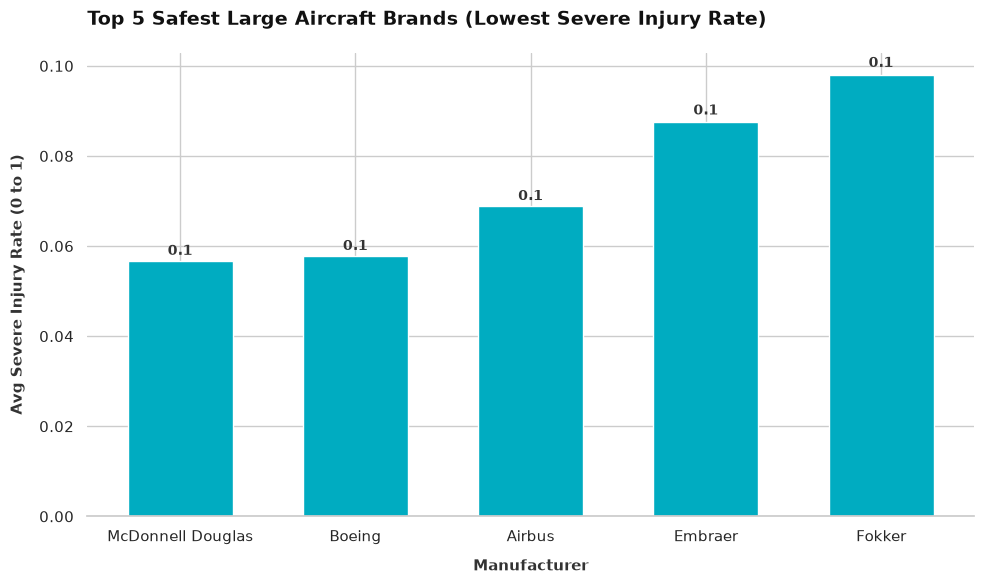

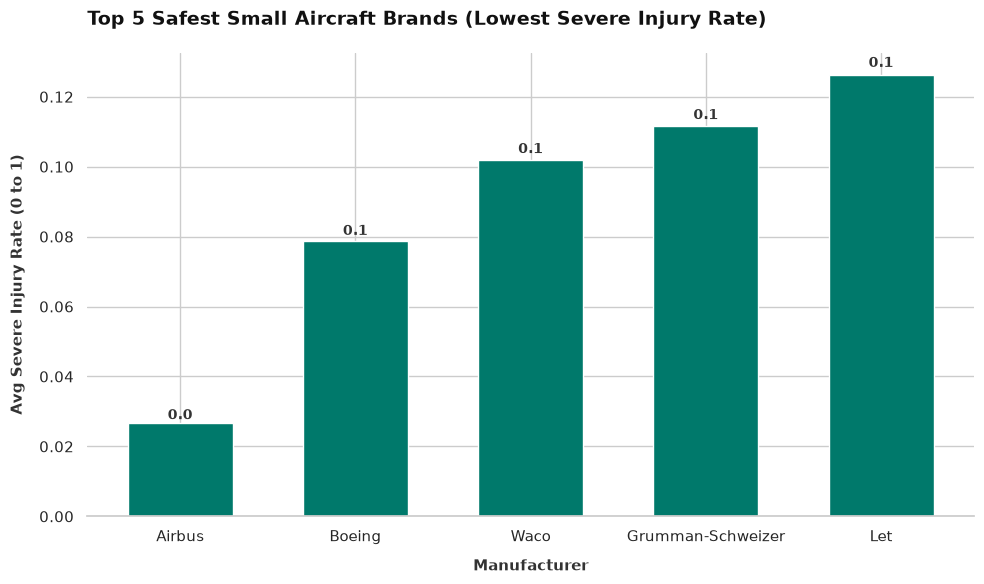

In [34]:
# Prepare top 5 safest large aircraft for plotting
top_large_plot = large_recommendations.head(5).reset_index()

# Plot Safest Large Aircraft Manufacturers
plot_charts(
    df=top_large_plot,
    x_col="Make",
    y_col="Avg_Severe_Injury_Rate",
    chart_type="bar",
    title="Top 5 Safest Large Aircraft Brands (Lowest Severe Injury Rate)",
    xlabel="Manufacturer",
    ylabel="Avg Severe Injury Rate (0 to 1)"
)

# Plot Safest Small Aircraft Manufacturers
top_small_plot = small_recommendations.head(5).reset_index()
plot_charts(
    df=top_small_plot,
    x_col="Make",
    y_col="Avg_Severe_Injury_Rate",
    chart_type="bar",
    title="Top 5 Safest Small Aircraft Brands (Lowest Severe Injury Rate)",
    xlabel="Manufacturer",
    ylabel="Avg Severe Injury Rate (0 to 1)",
    color="#00796b"
)

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'left': 'Safety Factor 2: Impact of Engine Count on Severe Injury Rates'}, xlabel='Number of Engines', ylabel='Avg Severe Injury Rate'>)

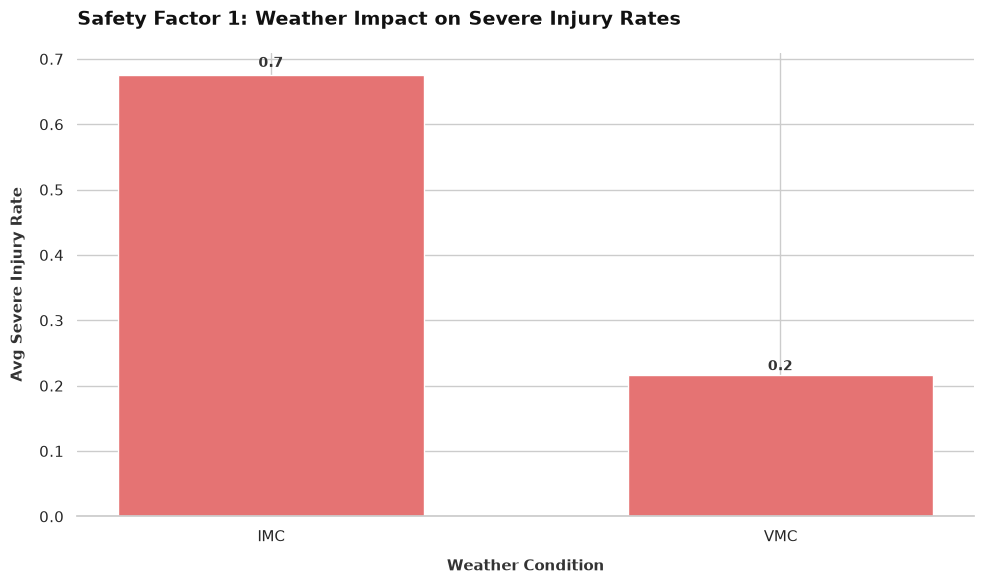

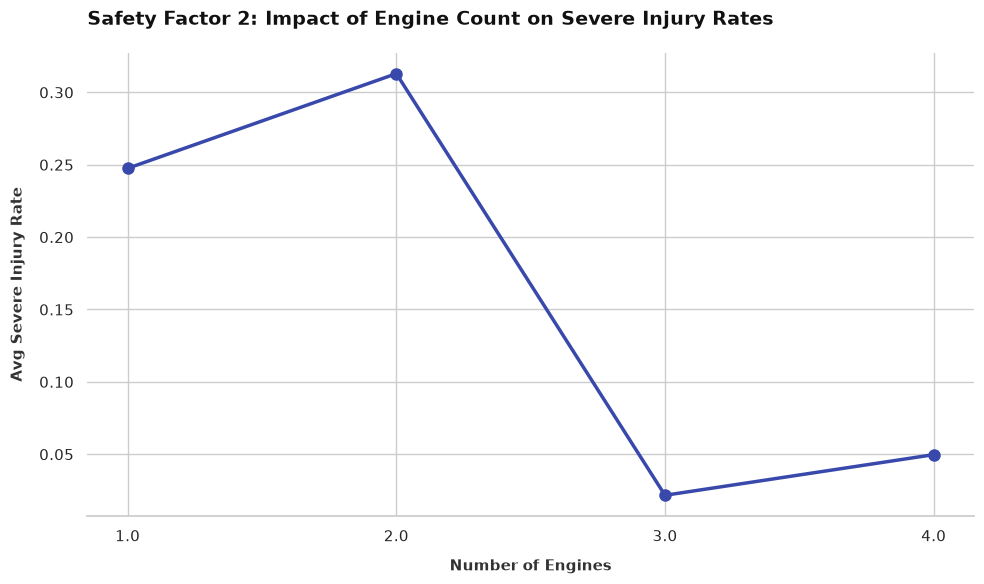

In [35]:
# FACTOR 1: Weather Conditions (Visualizing IMC vs VMC)
# IMC = Instrument Meteorological Conditions (poor visibility/stormy)
# VMC = Visual Meteorological Conditions (clear skies)

weather_safety = clean_df.groupby("Weather.Condition").agg(
    Total_Incidents=("Event.Id", "count"),
    Avg_Severe_Injury_Rate=("Severe_Injury_Rate", "mean")
).reset_index()

# Filter out unknown weather codes to keep it clean
weather_safety = weather_safety[weather_safety["Weather.Condition"].isin(["VMC", "IMC"])]

plot_charts(
    df=weather_safety,
    x_col="Weather.Condition",
    y_col="Avg_Severe_Injury_Rate",
    chart_type="bar",
    title="Safety Factor 1: Weather Impact on Severe Injury Rates",
    xlabel="Weather Condition",
    ylabel="Avg Severe Injury Rate",
    color="#e57373"
)

# FACTOR 2: Number of Engines
# Does having more engines mean lower severe injury rates?
engine_safety = clean_df.groupby("Number.of.Engines").agg(
    Total_Incidents=("Event.Id", "count"),
    Avg_Severe_Injury_Rate=("Severe_Injury_Rate", "mean")
).reset_index()

# Filter for the most common engine layouts (1, 2, 3, or 4 engines)
engine_safety = engine_safety[engine_safety["Number.of.Engines"].isin([1.0, 2.0, 3.0, 4.0])]

plot_charts(
    df=engine_safety,
    x_col="Number.of.Engines",
    y_col="Avg_Severe_Injury_Rate",
    chart_type="line",
    title="Safety Factor 2: Impact of Engine Count on Severe Injury Rates",
    xlabel="Number of Engines",
    ylabel="Avg Severe Injury Rate",
    color="#3949ab"
)

### Save DataFrame to csv
- its generally useful to save data to file/server after its in a sufficiently cleaned or intermediate state
- the data can then be loaded directly in another notebook for further analysis
- this helps keep your notebooks and workflow readable, clean and modularized

In [36]:
# Save the cleaned dataset so later notebooks (EDA, modeling) can load it directly
# without re-running this whole cleaning pipeline.
os.makedirs("data", exist_ok=True)
clean_df.to_csv("data/clean_aviation_data.csv", index=False)
print(f"Saved {clean_df.shape[0]} rows and {clean_df.shape[1]} columns to data/clean_aviation_data.csv")

Saved 52139 rows and 29 columns to data/clean_aviation_data.csv
